In [2]:
import os
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.windows import Window
import geopandas as gpd
import torch
from torch import nn
import torch.nn.functional as F
from transformers import SegformerForSemanticSegmentation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm import tqdm


C:\Users\user\anaconda3\envs\seg_cuda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:

# ============================ НАСТРОЙКИ ============================
TEST_DIR = r'D:\kanopus_ikutsk\preds\захламление'

# MODEL_PATH = 'best_model_segformer_hlam_main_40_2.pth' main версия
MODEL_PATH = 'best_model_segformer_hlam_hn.pth'
MODEL_NAME = "nvidia/segformer-b0-finetuned-ade-512-512"  # или b2
theshold = 0.5
PATCH_SIZE = 512
STRIDE = 256
BATCH_SIZE = 8
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используется устройство: {DEVICE}')


Используется устройство: cuda


In [11]:


# ============================ ЗАГРУЗКА МОДЕЛИ ============================
def load_model(model_name, model_path, in_channels=4, num_classes=2):
    # Загружаем предобученную модель
    model = SegformerForSemanticSegmentation.from_pretrained(
        model_name,
        num_labels=num_classes,
        ignore_mismatched_sizes=True,
        use_safetensors=True
    )
    # Адаптируем первый свёрточный слой под in_channels
    first_conv = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d) and module.in_channels == 3:
            first_conv = module
            break
    if first_conv is None:
        raise ValueError("Не найден свёрточный слой с 3 входными каналами")
    new_conv = nn.Conv2d(
        in_channels=in_channels,
        out_channels=first_conv.out_channels,
        kernel_size=first_conv.kernel_size,
        stride=first_conv.stride,
        padding=first_conv.padding,
        bias=first_conv.bias is not None
    )
    with torch.no_grad():
        new_conv.weight[:, :3] = first_conv.weight
        new_conv.weight[:, 3] = first_conv.weight[:, 0]  # дублируем канал
    # Заменяем слой
    for name, module in model.named_modules():
        if module is first_conv:
            parent_name = name.rsplit('.', 1)[0] if '.' in name else ''
            parent = model.get_submodule(parent_name) if parent_name else model
            attr_name = name.rsplit('.', 1)[-1] if '.' in name else name
            setattr(parent, attr_name, new_conv)
            break
    model.config.num_channels = in_channels
    # Загружаем обученные веса
    state_dict = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    model.to(DEVICE)
    model.eval()
    return model

model = load_model(MODEL_NAME, MODEL_PATH)
print('Модель загружена.')

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `150`.
Loading weights: 100%|██████████| 208/208 [00:00<00:00, 9904.92it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([2])                      

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Модель загружена.


C:\Users\user\AppData\Local\Temp\ipykernel_6364\258222978.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=DEVICE)


In [12]:
def geojson_to_mask(geojson_path, transform, out_shape):
    """Растеризация GeoJSON в маску."""
    gdf = gpd.read_file(geojson_path)
    if gdf.empty:
        return np.zeros(out_shape, dtype=np.uint8)
    shapes = [(geom, 1) for geom in gdf.geometry]
    mask = rasterize(shapes, out_shape=out_shape, transform=transform,
                     fill=0, dtype='uint8')
    return mask

def normalize_image(img):
    """Min-max нормализация по каждому каналу в [0, 1]."""
    img = img.astype(np.float32)
    for c in range(img.shape[0]):
        min_val = img[c].min()
        max_val = img[c].max()
        if max_val - min_val > 1e-6:
            img[c] = (img[c] - min_val) / (max_val - min_val)
        else:
            img[c] = 0
    return img
    
def sliding_window_inference(model, tif_path, patch_size=512, stride=256, batch_size=8):
    """Полное предсказание с взвешенным усреднением."""
    with rasterio.open(tif_path) as src:
        width, height = src.width, src.height

    prob_sum = np.zeros((height, width), dtype=np.float32)
    weight_sum = np.zeros((height, width), dtype=np.float32)

    # Гауссово окно для весов
    def create_weight_map(patch_size):
        ax = np.arange(patch_size)
        gauss = np.exp(-((ax - patch_size/2)**2) / (2*(patch_size/4)**2))
        weight = np.outer(gauss, gauss).astype(np.float32)
        return weight

    weight_map = create_weight_map(patch_size)

    # Список окон
    windows_list = []
    for y in range(0, height - patch_size + 1, stride):
        for x in range(0, width - patch_size + 1, stride):
            windows_list.append((x, y))

    for i in tqdm(range(0, len(windows_list), batch_size), desc='Inference'):
        batch_windows = windows_list[i:i+batch_size]
        batch_imgs = []
        batch_coords = []
        for x, y in batch_windows:
            with rasterio.open(tif_path) as src:
                window = Window(x, y, patch_size, patch_size)
                img = src.read(window=window)
            img = normalize_image(img)
            batch_imgs.append(img)
            batch_coords.append((x, y))

        imgs_tensor = torch.stack([torch.tensor(im, dtype=torch.float32) for im in batch_imgs]).to(DEVICE)
        with torch.no_grad():
            outputs = model(imgs_tensor)
            logits = outputs.logits
            logits = F.interpolate(logits, size=(patch_size, patch_size), mode='bilinear', align_corners=False)
            probs = torch.softmax(logits, dim=1)[:, 1]  # вероятность класса 1
            probs_np = probs.cpu().numpy()

        for (x, y), prob in zip(batch_coords, probs_np):
            prob_sum[y:y+patch_size, x:x+patch_size] += prob * weight_map
            weight_sum[y:y+patch_size, x:x+patch_size] += weight_map

    full_prob = prob_sum / np.maximum(weight_sum, 1e-6)
    pred_mask = (full_prob > theshold).astype(np.uint8)
    return pred_mask, full_prob

In [13]:

# ============================ ОБРАБОТКА ТЕСТОВЫХ СЦЕН ============================
# Получаем список пар файлов
test_files = []
for fname in os.listdir(TEST_DIR):
    if fname.lower().endswith('.tif'):
        base = os.path.splitext(fname)[0]
        geojson_name = base + '.geojson'
        geojson_path = os.path.join(TEST_DIR, geojson_name)
        if os.path.exists(geojson_path):
            test_files.append((os.path.join(TEST_DIR, fname), geojson_path))

print(f'Найдено тестовых сцен: {len(test_files)}')

Найдено тестовых сцен: 10


In [14]:

# ============================ ФУНКЦИЯ ВИЗУАЛИЗАЦИИ ============================
def visualize_predictions(tif_path, geojson_path, pred_mask, true_mask, num_examples=6):
    """Показывает несколько случайных патчей с наложением истины и предсказания."""
    with rasterio.open(tif_path) as src:
        width, height = src.width, src.height

    # Выбираем случайные окна, полностью внутри изображения
    candidates = []
    for y in range(0, height - PATCH_SIZE + 1, PATCH_SIZE):
        for x in range(0, width - PATCH_SIZE + 1, PATCH_SIZE):
            candidates.append((x, y))
    selected = np.random.choice(len(candidates), min(num_examples, len(candidates)), replace=False)

    fig, axes = plt.subplots(len(selected), 3, figsize=(15, 5*len(selected)))
    for i, idx in enumerate(selected):
        x, y = candidates[idx]
        with rasterio.open(tif_path) as src:
            window = Window(x, y, PATCH_SIZE, PATCH_SIZE)
            img = src.read(window=window)
        img_rgb = np.stack([img[2], img[1], img[0]], axis=-1).astype(np.float32)
        # Растяжение для отображения
        def stretch(ch):
            low, high = np.percentile(ch, 2), np.percentile(ch, 98)
            if high - low < 1e-6:
                return np.zeros_like(ch)
            return np.clip((ch - low) / (high - low), 0, 1)
        img_disp = np.zeros_like(img_rgb)
        for c in range(3):
            img_disp[..., c] = stretch(img_rgb[..., c])

        true_patch = true_mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
        pred_patch = pred_mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

        axes[i, 0].imshow(img_disp)
        axes[i, 0].set_title('Исходное изображение')
        axes[i, 0].axis('off')
        axes[i, 1].imshow(true_patch, cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title('Истинная маска')
        axes[i, 1].axis('off')
        axes[i, 2].imshow(pred_patch, cmap='gray', vmin=0, vmax=1)
        axes[i, 2].set_title('Предсказанная маска')
        axes[i, 2].axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:


all_targets = []
all_preds = []

for tif_path, geojson_path in test_files:
    print(f'Обработка: {os.path.basename(tif_path)}')
    # Читаем TIF для получения transform и размеров
    with rasterio.open(tif_path) as src:
        transform = src.transform
        width, height = src.width, src.height
    # Растеризуем истинную маску
    true_mask = geojson_to_mask(geojson_path, transform, (height, width))
    # Предсказание
    pred_mask, _ = sliding_window_inference(model, tif_path, PATCH_SIZE, STRIDE, BATCH_SIZE)

    # Сохраняем результаты для суммарных метрик
    all_targets.append(true_mask.flatten())
    all_preds.append(pred_mask.flatten())

    # Метрики для текущей сцены
    # print(f'--- Метрики для {os.path.basename(tif_path)} ---')
    # print(classification_report(true_mask.flatten(), pred_mask.flatten(), target_names=['фон', 'захламление']))
    # Визуализация нескольких патчей
    # visualize_predictions(tif_path, geojson_path, pred_mask, true_mask, num_examples=20)



=== Общие метрики по всем тестовым сценам ===
              precision    recall  f1-score   support

         фон       0.99      0.99      0.99  22380807
 захламление       0.80      0.87      0.84   1212153

    accuracy                           0.98  23592960
   macro avg       0.90      0.93      0.91  23592960
weighted avg       0.98      0.98      0.98  23592960



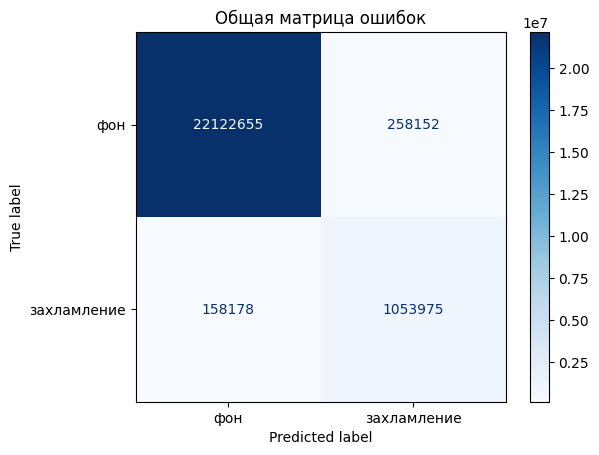

In [16]:

# Общие метрики
all_targets = np.concatenate(all_targets)
all_preds = np.concatenate(all_preds)
print('\n=== Общие метрики по всем тестовым сценам ===')
print(classification_report(all_targets, all_preds, target_names=['фон', 'захламление']))

# Матрица ошибок
cm = confusion_matrix(all_targets, all_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['фон', 'захламление'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Общая матрица ошибок')
plt.show()



=== Общие метрики по всем тестовым сценам ===
              precision    recall  f1-score   support

         фон       1.00      0.98      0.99  22380807
 захламление       0.75      0.94      0.84   1212153

    accuracy                           0.98  23592960
   macro avg       0.87      0.96      0.91  23592960
weighted avg       0.98      0.98      0.98  23592960



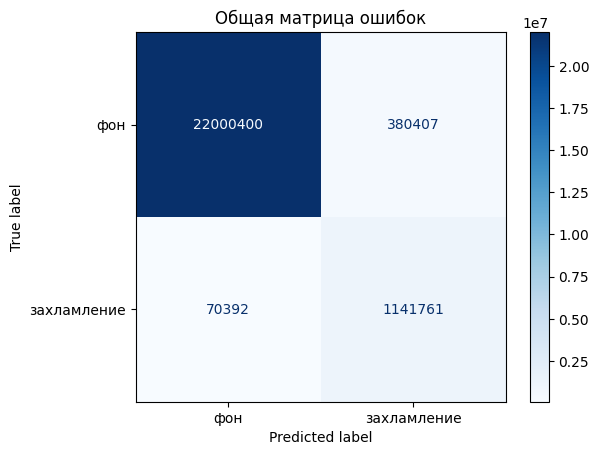

In [41]:

# Общие метрики
all_targets = np.concatenate(all_targets)
all_preds = np.concatenate(all_preds)
print('\n=== Общие метрики по всем тестовым сценам ===')
print(classification_report(all_targets, all_preds, target_names=['фон', 'захламление']))

# Матрица ошибок
cm = confusion_matrix(all_targets, all_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['фон', 'захламление'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Общая матрица ошибок')
plt.show()



=== Общие метрики по всем тестовым сценам ===
              precision    recall  f1-score   support

         фон       1.00      0.98      0.99  22380807
 захламление       0.73      0.95      0.82   1212153

    accuracy                           0.98  23592960
   macro avg       0.86      0.97      0.91  23592960
weighted avg       0.98      0.98      0.98  23592960



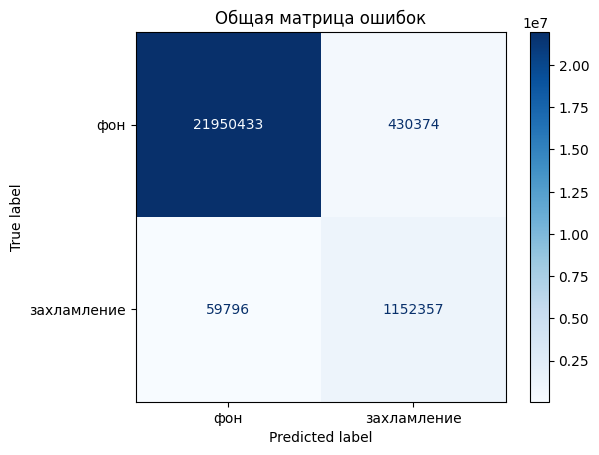

In [38]:

# Общие метрики
all_targets = np.concatenate(all_targets)
all_preds = np.concatenate(all_preds)
print('\n=== Общие метрики по всем тестовым сценам ===')
print(classification_report(all_targets, all_preds, target_names=['фон', 'захламление']))

# Матрица ошибок
cm = confusion_matrix(all_targets, all_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['фон', 'захламление'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Общая матрица ошибок')
plt.show()



=== Общие метрики по всем тестовым сценам ===
              precision    recall  f1-score   support

         фон       0.99      0.97      0.98  22380807
 захламление       0.55      0.75      0.64   1212153

    accuracy                           0.96  23592960
   macro avg       0.77      0.86      0.81  23592960
weighted avg       0.96      0.96      0.96  23592960



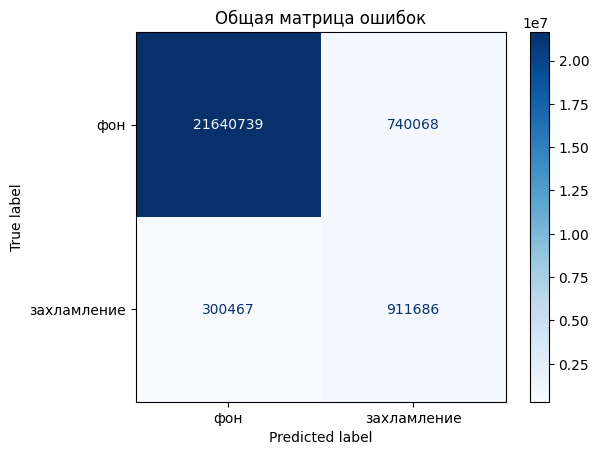

In [30]:

# Общие метрики
all_targets = np.concatenate(all_targets)
all_preds = np.concatenate(all_preds)
print('\n=== Общие метрики по всем тестовым сценам ===')
print(classification_report(all_targets, all_preds, target_names=['фон', 'захламление']))

# Матрица ошибок
cm = confusion_matrix(all_targets, all_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['фон', 'захламление'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Общая матрица ошибок')
plt.show()
